## Cyclistic User Behavior & Membership Conversion Analysis 
---

### Problem Statement

Cyclistic aims to increase profitability by converting casual riders into annual members. This project analyzes behavioral differences, identifies high-conversion user segments, and uncovers actionable opportunities to drive membership growth through targeted marketing and product strategies.


#### Business Context

Cyclistic operates a bike-share program with two primary customer types: casual riders and annual members. While casual riders contribute to short-term revenue, annual members provide more stable and predictable income streams. Converting casual riders into members is therefore a key strategic priority for long-term growth.

### Dataset

#### Data Source Overview
The analysis uses Cyclistic’s historical trip data, which contains detailed records of individual bike rides over a 12-month period. The data has been made available by **Motivate International Inc.** under this [license](https://divvybikes.com/data-license-agreement).

The data is provided as multiple monthly CSV files, each containing trip-level information. These files were combined into a single dataset to enable comprehensive annual analysis and to capture seasonal patterns in rider behavior.

#### Dataset Structure

Each row in the dataset represents a single bike trip. The dataset includes the following key variables:
- `ride_id` – unique identifier for each trip
- `rideable_type` – type of bike used (e.g., classic, electric)
- `started_at` – timestamp when the trip began
- `ended_at` – timestamp when the trip ended
- `start_station_name` – name of the starting station
- `start_station_id` - unique identifier of the start station
- `end_station_name` – name of the ending station
- `end_station_id` - unique identifier of the end station
- `start_lat / start_lng` – geographic coordinates of the start location
- `end_lat / end_lng` – geographic coordinates of the end location
- `member_casual` – user type (annual member or casual rider)
  
The most critical variable for this analysis is member_casual, as it allows for segmentation and comparison between the two user groups.

#### Time Period Covered
The dataset spans a full 12-month period (March 2025 - February 2026), which enables analysis of:
- seasonal trends
- monthly usage patterns
- weekday vs weekend behavior, etc.
  
Using a full year of data ensures that the analysis captures both peak and off-peak usage periods.

#### Data Limitations
While the dataset is rich in behavioral information, it has several limitations that should be acknowledged:
- **No demographic data**
    - The dataset does not include age, gender, income, or other demographic variables, limiting the ability to profile users beyond behavior.
- **No direct customer intent**
    - The data shows what users did, but not why they chose casual or annual usage.
- **Missing or incomplete station data**
    - Some records may contain null or inconsistent station names or coordinates.
- **Potential data quality issues**
    - Errors such as extremely short or unusually long ride durations may exist and require cleaning.
- **Geographic context is limited**
    - While coordinates are provided, the dataset does not explicitly label locations as residential, commercial, or tourist areas.

### Import Python libraries

In [399]:
import pandas as pd
import numpy as np
import glob
import os
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

### Set global style for plot

In [400]:
plt.rcParams['figure.figsize'] = (5, 3)
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

### Import data

The raw monthly Cyclistic trip data files were programmatically loaded from a designated directory using Python. File paths were dynamically retrieved and sorted chronologically based on their embedded month and year to ensure correct temporal sequencing. Each dataset was then read and combined into a single unified dataframe. The started_at column was converted to a datetime format, and the merged dataset was sorted by trip start time to preserve chronological integrity for accurate time-based analysis.

In [401]:
data_path = os.path.expanduser("../data/raw_data")
files = glob.glob(os.path.join(data_path, "*.csv"))

# Sort files chronologically
def extract_date(file):
    match = re.search(r'(\w+)_(\d{4})', file)
    if match:
        month, year = match.groups()
        return pd.to_datetime(f"{month} {year}", format="%b %Y")
    return pd.NaT

files = sorted(files, key=extract_date)

# Load and merge
df_list = []

for file in files:
    df = pd.read_csv(file)
    df_list.append(df)

combined_df = pd.concat(df_list, ignore_index=True)

# Convert datetime and sort dataset
combined_df['started_at'] = pd.to_datetime(combined_df['started_at'], errors='coerce')
combined_df = combined_df.sort_values(by='started_at').reset_index(drop=True)

print(combined_df.shape)
print(combined_df['started_at'].min())

(5601662, 13)
2025-02-28 08:06:36.009000


### Merge data


The raw Cyclistic data files were loaded from a folder using Python. All CSV files in the folder were automatically found and read into separate dataframes. These dataframes were then combined into one single dataset, which was used for further checking and analysis.

In [402]:
data_path = os.path.expanduser("../data/raw_data")
files = glob.glob(os.path.join(data_path, "*.csv"))

df_list = []

for file in files:
    df = pd.read_csv(file)
    df_list.append(df)

combined_df = pd.concat(df_list, ignore_index=True)

print(combined_df.shape)
combined_df.head(2)

(5601662, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,E555D9F8E9C2F56B,electric_bike,2025-11-04 00:09:07.792,2025-11-04 00:15:04.661,NaN,NaN,NaN,NaN,41.94,-87.67,41.94,-87.67,casual
1,EAEBE70DBF015886,electric_bike,2025-11-04 14:32:09.067,2025-11-04 14:36:43.998,NaN,NaN,NaN,NaN,41.90,-87.64,41.91,-87.64,casual


### Data Validation
Validate the merged dataset before cleaning and feature engineering.

#### 1. Confirm full-time coverage

In [403]:
combined_df['started_at'] = pd.to_datetime(combined_df['started_at'], errors='coerce')

print("Earliest date:", combined_df['started_at'].min())
print("Latest date:", combined_df['started_at'].max())

Earliest date: 2025-02-28 08:06:36.009000
Latest date: 2026-02-28 23:57:54.093000


#### 2. Confirm all months are present

In [404]:
combined_df['month_year'] = combined_df['started_at'].dt.to_period('M')

print(combined_df['month_year'].value_counts().sort_index())

month_year
2025-02        36
2025-03    298130
2025-04    371376
2025-05    502615
2025-06    678801
2025-07    763458
2025-08    790317
2025-09    714562
2025-10    646096
2025-11    356512
2025-12    140545
2026-01    137782
2026-02    201432
Freq: M, Name: count, dtype: int64


#### 3. Check duplicate ride_IDs

In [405]:
combined_df['ride_id'].duplicated().sum()

0

#### 4. Check missing values

In [406]:
combined_df.isna().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1192515
start_station_id      1192515
end_station_name      1254439
end_station_id        1254439
start_lat                   0
start_lng                   0
end_lat                  5742
end_lng                  5742
member_casual               0
month_year                  0
dtype: int64

#### 5. Sanity check categories

In [407]:
combined_df['member_casual'].value_counts()
combined_df['rideable_type'].value_counts()

rideable_type
electric_bike    3645132
classic_bike     1956530
Name: count, dtype: int64

### Data Cleaning

#### 1. Remove duplicate records

Duplicate records were removed from the dataset using the unique ride ID to ensure that each trip was counted only once. A preview of the cleaned dataset was then displayed to verify the changes.

In [408]:
combined_df = combined_df.drop_duplicates(subset='ride_id')
combined_df.head(1)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,month_year
0,E555D9F8E9C2F56B,electric_bike,2025-11-04 00:09:07.792,2025-11-04 00:15:04.661,NaN,NaN,NaN,NaN,41.94,-87.67,41.94,-87.67,casual,2025-11


#### 2. Handle missing values
Rows with missing values in important columns such as ride ID, start time, end time, and rider type were removed to ensure the dataset is complete and reliable for analysis.

In [409]:
combined_df = combined_df.dropna(subset=[
    'ride_id',
    'started_at',
    'ended_at',
    'member_casual'
])

#### 3. Convert Datetime Columns 

The start and end time columns were converted into datetime format to ensure they can be used for time-based calculations and analysis. Any invalid values were handled safely during the conversion process.

In [410]:
combined_df['started_at'] = pd.to_datetime(combined_df['started_at'], errors='coerce')
combined_df['ended_at'] = pd.to_datetime(combined_df['ended_at'], errors='coerce')

#### 4. Create ride duration

A new column was created to calculate the ride duration in minutes by subtracting the start time from the end time. This allows for easier analysis of how long each trip lasts.

In [411]:
combined_df['ride_length_minutes'] = (
    (combined_df['ended_at'] - combined_df['started_at']).dt.total_seconds() / 60
)

In [412]:
combined_df['ride_length_minutes'].describe()

count    5.601662e+06
mean     1.609627e+01
std      5.581241e+01
min     -5.479480e+01
25%      5.397617e+00
50%      9.434150e+00
75%      1.658598e+01
max      1.574900e+03
Name: ride_length_minutes, dtype: float64

The summary statistics showed that most rides are relatively short, with a median duration of around 9 minutes. However, the dataset also contained negative and extremely long ride durations, indicating data quality issues. These outliers were removed to ensure more accurate and reliable analysis.

#### 5. Remove invalid durations
Rows with invalid ride durations were removed by filtering out trips with negative or zero values, as well as rides longer than 24 hours, to ensure the data is realistic and suitable for analysis.

In [413]:
combined_df = combined_df[combined_df['ride_length_minutes'] > 0]
combined_df = combined_df[combined_df['ride_length_minutes'] <= 1440]

### Feature Engineering

#### 1. Create time-based features
New time-based columns were created from the start time, including date, year, month, day, day of the week, and hour, to support detailed time-based analysis of ride patterns.

In [414]:
combined_df['date'] = combined_df['started_at'].dt.date
combined_df['year'] = combined_df['started_at'].dt.year
combined_df['month'] = combined_df['started_at'].dt.month
combined_df['month_name'] = combined_df['started_at'].dt.month_name()
combined_df['day'] = combined_df['started_at'].dt.day
combined_df['day_of_week'] = combined_df['started_at'].dt.day_name()
combined_df['hour'] = combined_df['started_at'].dt.hour

#### 2. Weekday vs Weekend (High Value)
A new column was created to classify each ride as either a weekday or weekend based on the day of the week, making it easier to compare riding patterns between workdays and leisure days.

In [415]:
combined_df['day_type'] = np.where(
    combined_df['day_of_week'].isin(['Saturday', 'Sunday']),
    'Weekend',
    'Weekday'
)

#### 3. Time of day segmentation

A function was created to group each ride into time-of-day categories such as morning, afternoon, evening, and night based on the hour, allowing for easier analysis of riding patterns throughout the day.

In [416]:
def time_segment(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

combined_df['time_segment'] = combined_df['hour'].apply(time_segment)

#### 4. Season

A new column was created to assign each ride to a season based on the month, helping to analyze how riding patterns change throughout the year.

In [417]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

combined_df['season'] = combined_df['month'].apply(get_season)

#### 5. Commute Behavior Proxy
A new column was created to identify rides that occur during typical weekday commute hours, helping to approximate commuting behavior based on time patterns.

In [418]:
combined_df['is_commute_hour'] = np.where(
    ((combined_df['hour'].between(7, 9)) | (combined_df['hour'].between(16, 18))) &
    (combined_df['day_type'] == 'Weekday'),
    1,
    0
)

#### 6. Ride length category
A new column was created to group ride durations into categories such as short, medium, long, and very long, making it easier to analyze and compare trip lengths.

In [419]:
def ride_length_category(x):
    if x < 10:
        return 'Short'
    elif x < 30:
        return 'Medium'
    elif x < 60:
        return 'Long'
    else:
        return 'Very Long'

combined_df['ride_length_category'] = combined_df['ride_length_minutes'].apply(ride_length_category)

### Data Validation Summary

A validation summary was created to review the overall dataset, including its size, missing values across all columns, duplicate ride IDs, distribution of rider types, and key statistics for ride duration, ensuring the data is accurate and ready for analysis.

In [420]:
print("="*60)
print("DATASET VALIDATION SUMMARY")
print("="*60)

# Dataset shape
rows, cols = combined_df.shape
print(f"\nDataset Shape: {rows:,} rows × {cols} columns")

# Missing values (ALL columns)
print("\nMissing Values (All Columns):")
missing = combined_df.isna().sum().sort_values(ascending=False)
print(missing)

# Duplicate ride_id
duplicates = combined_df['ride_id'].duplicated().sum()
print(f"\nDuplicate ride_id count: {duplicates:,}")

# Member type distribution
print("\nMember Type Distribution:")
print(combined_df['member_casual'].value_counts())

# Ride length summary
print("\nRide Length Summary (minutes):")
print(combined_df['ride_length_minutes'].describe())

print("\n" + "="*60)

DATASET VALIDATION SUMMARY

Dataset Shape: 5,595,869 rows × 27 columns

Missing Values (All Columns):
end_station_name        1248792
end_station_id          1248792
start_station_name      1192511
start_station_id        1192511
end_lat                     186
end_lng                     186
ride_id                       0
month                         0
is_commute_hour               0
season                        0
time_segment                  0
day_type                      0
hour                          0
day_of_week                   0
day                           0
month_name                    0
month_year                    0
year                          0
date                          0
ride_length_minutes           0
rideable_type                 0
member_casual                 0
start_lng                     0
start_lat                     0
ended_at                      0
started_at                    0
ride_length_category          0
dtype: int64

Duplicate ride_id co

### Fill Missing Station Names and IDs
Missing values in station-related columns were replaced with “Unknown” to retain all records while ensuring consistency for analysis and visualization.

In [421]:
combined_df['start_station_name'] = combined_df['start_station_name'].fillna('Unknown')
combined_df['end_station_name'] = combined_df['end_station_name'].fillna('Unknown')

combined_df['start_station_id'] = combined_df['start_station_id'].fillna('Unknown')
combined_df['end_station_id'] = combined_df['end_station_id'].fillna('Unknown')

In [422]:
print(combined_df[['start_station_name', 'end_station_name']].isna().sum())

start_station_name    0
end_station_name      0
dtype: int64


### Drop Missing End Latitude and Longitude

A small number of rows with missing end location coordinates were removed due to their minimal impact on the overall dataset. This ensured data consistency without significantly reducing the dataset size.


In [423]:
combined_df = combined_df.dropna(subset=['end_lat', 'end_lng'])
print(combined_df[['end_lat', 'end_lng']].isna().sum())

end_lat    0
end_lng    0
dtype: int64


In [424]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5595683 entries, 0 to 5601661
Data columns (total 27 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ride_id               object        
 1   rideable_type         object        
 2   started_at            datetime64[ns]
 3   ended_at              datetime64[ns]
 4   start_station_name    object        
 5   start_station_id      object        
 6   end_station_name      object        
 7   end_station_id        object        
 8   start_lat             float64       
 9   start_lng             float64       
 10  end_lat               float64       
 11  end_lng               float64       
 12  member_casual         object        
 13  month_year            period[M]     
 14  ride_length_minutes   float64       
 15  date                  object        
 16  year                  int32         
 17  month                 int32         
 18  month_name            object        
 19  day  

### Sort Data

After completing data cleaning and feature engineering, the dataset was sorted by trip start time to ensure chronological consistency for time-based analysis.

In [425]:
combined_df = combined_df.sort_values(by='started_at').reset_index(drop=True)

In [426]:
print(combined_df['started_at'].head())

0   2025-02-28 19:20:43.552
1   2025-02-28 22:36:36.978
2   2025-02-28 23:26:10.493
3   2025-02-28 23:45:18.167
4   2025-02-28 23:50:32.627
Name: started_at, dtype: datetime64[ns]


In [447]:
combined_df.head(1)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,month,month_name,day,day_of_week,hour,day_type,time_segment,season,is_commute_hour,ride_length_category
0,2C8C21C83E2E7B07,classic_bike,2025-02-28 19:20:43.552,2025-03-01 12:03:12.050,Sheffield Ave & Webster Ave,TA1309000033,Larrabee St & Menomonee St,TA1306000007,41.92154,-87.653818,...,2,February,28,Friday,19,Weekday,Evening,Winter,0,Very Long


In [428]:
combined_df.tail(1)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,month,month_name,day,day_of_week,hour,day_type,time_segment,season,is_commute_hour,ride_length_category
5595682,4F35A46FCB71CF46,classic_bike,2026-02-28 23:57:54.093,2026-02-28 23:59:37.711,Broadway & Berwyn Ave,CHI00414,Sheridan Rd & Berwyn Ave,CHI02155,41.978361,-87.659789,...,2,February,28,Saturday,23,Weekend,Night,Winter,0,Short


### Export final dataset

The final cleaned dataset was exported from Jupyter Notebook as a CSV file, enabling seamless integration with Tableau for visualization and dashboard development.

In [450]:
# Create folder if it doesn't exist
output_folder = "../data/processed"
os.makedirs(output_folder, exist_ok=True)

# Define file path
file_path = os.path.join(output_folder, "cyclistic_final.csv")

# Export
combined_df.to_csv(file_path, index=False)

print("File saved at:", file_path)

File saved at: ../data/processed/cyclistic_final.csv


In [451]:
test_df = pd.read_csv(file_path)
print(test_df.shape)
test_df.head(1)

(5595683, 27)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,month,month_name,day,day_of_week,hour,day_type,time_segment,season,is_commute_hour,ride_length_category
0,2C8C21C83E2E7B07,classic_bike,2025-02-28 19:20:43.552,2025-03-01 12:03:12.050,Sheffield Ave & Webster Ave,TA1309000033,Larrabee St & Menomonee St,TA1306000007,41.92154,-87.653818,...,2,February,28,Friday,19,Weekday,Evening,Winter,0,Very Long


## Advance Analysis

In [429]:
# Consistent plot style
def style_plot(title, xlabel, ylabel):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()

# Consistent colors
colors = ['#1f77b4', '#ff7f0e']  # member, casual

### 1. Baseline Comparison 


#### Ride Percentage by User Type

Members account for the majority of rides at approximately 64%, while casual riders make up about 36%, indicating that members are the primary users of the bike-share system.

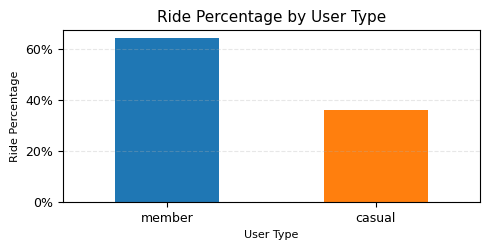

member_casual
member    64.104096
casual    35.895904
Name: proportion, dtype: float64


In [430]:
proportion = combined_df['member_casual'].value_counts(normalize=True)

ax = proportion.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

style_plot(
    "Ride Percentage by User Type",
    "User Type",
    "Ride Percentage"
)
plt.xticks(rotation=0)
plt.show()

plt.show()
print(usage)

#### Ride Length by User Type (Median)
Casual riders have a higher median ride length than members, indicating they tend to take longer trips, while members typically use bikes for shorter, more frequent rides.

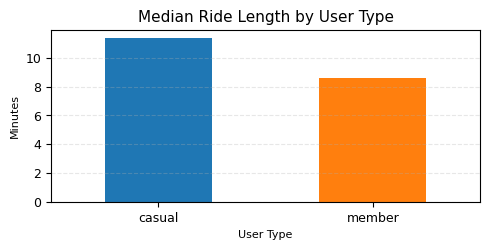

In [431]:
combined_df.groupby('member_casual')['ride_length_minutes'].median().plot(
    kind='bar',
    color=colors
)

style_plot(
    "Median Ride Length by User Type",
    "User Type",
    "Minutes"
)
plt.xticks(rotation=0)
plt.show()

### 2. Time-Based Behavioral Analysis

#### Weekday vs. Weekend Usage

Members primarily ride on weekdays, showing a strong commuting pattern, while casual riders are more evenly distributed between weekdays and weekends, indicating a mix of commuting and leisure usage.

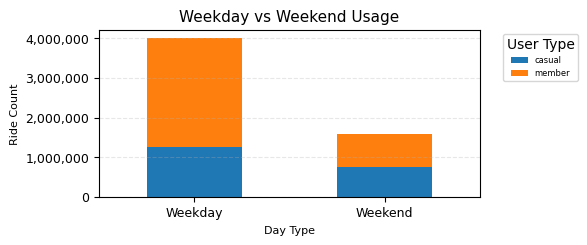

member_casual   casual   member
day_type                       
Weekday        1260701  2752190
Weekend         747920   834872


In [432]:
day_type = combined_df.groupby(['day_type', 'member_casual']).size().unstack()

day_type.plot(kind='bar', stacked=True, color=colors)

# Comma formatting
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

style_plot(
    "Weekday vs Weekend Usage",
    "Day Type",
    "Ride Count"
)

# Legend setting
plt.legend(
    title="User Type",
    bbox_to_anchor=(1.05, 1),
    loc='upper left')

plt.xticks(rotation=0)
plt.show()
print(day_type)

#### Rides by Day of Week
Members show consistent usage throughout the weekdays with slight peaks midweek, while casual riders increase significantly toward the weekend, peaking on Saturday, indicating stronger leisure usage patterns.

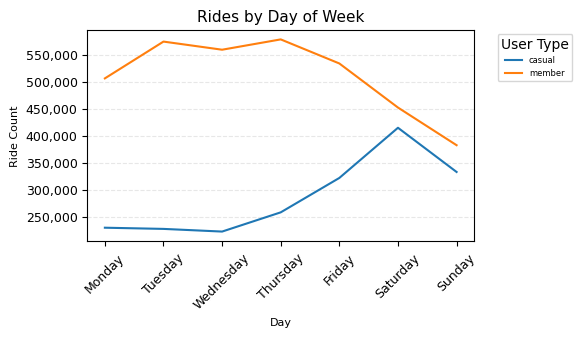

In [433]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow = combined_df.groupby(['day_of_week', 'member_casual']).size().unstack()
dow = dow.reindex(day_order)

dow.plot(color=colors)
# Comma formatting
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

style_plot(
    "Rides by Day of Week",
    "Day",
    "Ride Count"
)

# Legend setting
plt.legend(
    title="User Type",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.xticks(rotation=45)
plt.show()

#### Hourly Ride Patters by User Type
Members show clear peaks during morning and evening commute hours, indicating work-related usage, while casual riders gradually increase throughout the day and peak in the late afternoon, reflecting more flexible and leisure-oriented riding patterns.

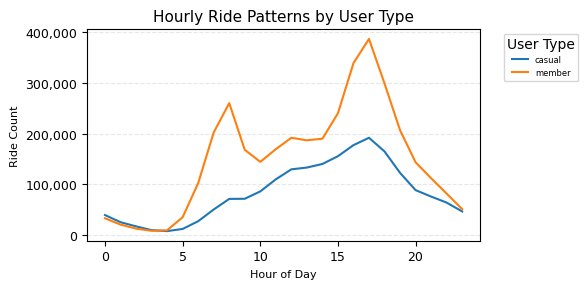

In [434]:
hourly = combined_df.groupby(['hour', 'member_casual']).size().unstack()

hourly.plot(color=colors)

# Comma formatting
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

style_plot(
    "Hourly Ride Patterns by User Type",
    "Hour of Day",
    "Ride Count"
)
# Legend setting
plt.legend(
    title="User Type",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.show()

### 3. Ride Duration Behavior

#### Ride Length Distribution by User Type
Most rides for both groups fall within the short and medium categories, but casual riders have a higher proportion of long and very long trips, indicating more extended, leisure-oriented usage compared to members.

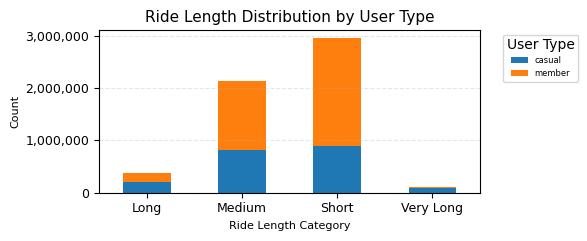

member_casual         casual   member
ride_length_category                 
Long                  207401   169248
Medium                820587  1324427
Short                 888051  2070795
Very Long              92582    22592


In [435]:
length = combined_df.groupby(['ride_length_category', 'member_casual']).size().unstack()

length.plot(kind='bar', stacked=True)

# Comma formatting
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

style_plot(
    title="Ride Length Distribution by User Type",
    xlabel="Ride Length Category",
    ylabel="Count"
)
# Legend setting
plt.legend(
    title="User Type",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.xticks(rotation=0)
plt.show()
print(length)

#### Median Ride Length by Day Type
Ride durations are longer on weekends for both groups, with casual riders consistently taking longer trips than members, reinforcing the pattern of leisure-focused usage during weekends.

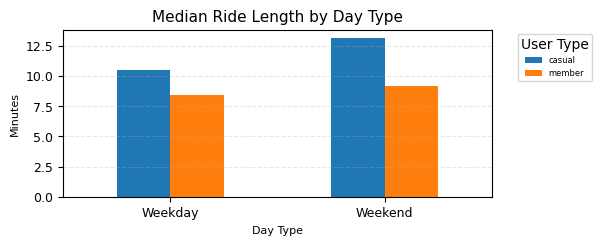

member_casual     casual    member
day_type                          
Weekday        10.476733  8.433025
Weekend        13.154192  9.165600


In [436]:
duration_day = combined_df.groupby(['day_type', 'member_casual'])['ride_length_minutes'].median().unstack()

duration_day.plot(kind='bar', color=colors)

style_plot(
    "Median Ride Length by Day Type",
    "Day Type",
    "Minutes"
)
# Legend setting
plt.legend(
    title="User Type",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.xticks(rotation=0)
plt.show()
print(duration_day)

### 4. Behavioral Segmentation

#### Commute Hour Usage
Members have significantly higher ride counts during commute hours compared to casual riders, indicating consistent work-related usage, while casual riders show lower but notable activity during these periods, suggesting potential for conversion.

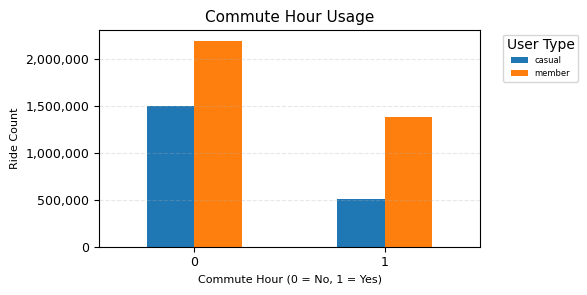

member_casual     casual   member
is_commute_hour                  
0                1499893  2200943
1                 508728  1386119


In [437]:
commute = combined_df.groupby(['is_commute_hour', 'member_casual']).size().unstack()

commute.plot(kind='bar', color=colors)

# Comma formatting
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

style_plot(
    "Commute Hour Usage",
    "Commute Hour (0 = No, 1 = Yes)",
    "Ride Count"
)

# Legend setting
plt.legend(
    title="User Type",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.xticks(rotation=0)
plt.show()
print(commute)

#### Ride Distribution by Time of Day
Members show strong usage during morning and evening periods, aligning with commute times, while casual riders are most active in the afternoon, reflecting more flexible and leisure-driven riding behavior.

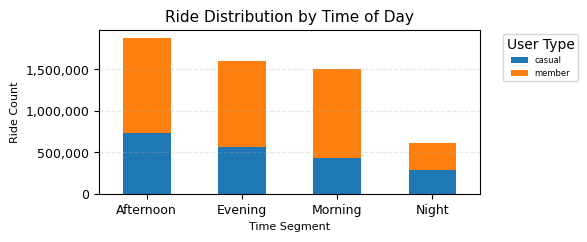

member_casual  casual   member
time_segment                  
Afternoon      734043  1146527
Evening        566746  1035376
Morning        425607  1079669
Night          282225   325490


In [438]:
time_seg = combined_df.groupby(['time_segment', 'member_casual']).size().unstack()

time_seg.plot(kind='bar', stacked=True, color=colors)

# Comma formatting
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

style_plot(
    "Ride Distribution by Time of Day",
    "Time Segment",
    "Ride Count"
)

# Legend setting
plt.legend(
    title="User Type",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.xticks(rotation=0)
plt.show()
print(time_seg)

#### Seasonal Ride Patterns
Ride activity peaks during the summer for both groups, with members consistently having higher usage across all seasons, while winter shows the lowest activity, indicating strong seasonality in bike usage.

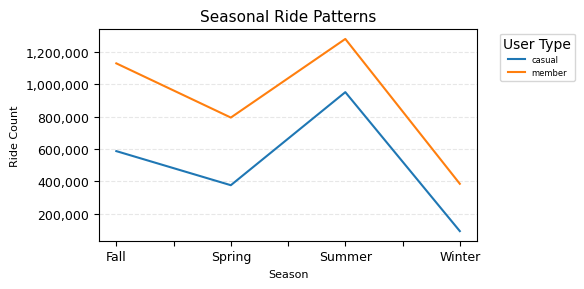

member_casual  casual   member
season                        
Fall           587162  1128394
Spring         376881   794067
Summer         950835  1279016
Winter          93743   385585


In [452]:
seasonal = combined_df.groupby(['season', 'member_casual']).size().unstack()

season.plot(kind='line', color=colors)

# Comma formatting
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

style_plot(
    "Seasonal Ride Patterns",
    "Season",
    "Ride Count"
)
# Legend setting
plt.legend(
    title="User Type",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.xticks(rotation=0)
plt.show()
print(seasonal)

#### Median Ride Length by Bike Type
Casual riders have longer median ride durations across both bike types, especially with classic bikes, while members show shorter and more consistent ride lengths, indicating more efficient and routine usage regardless of bike type.

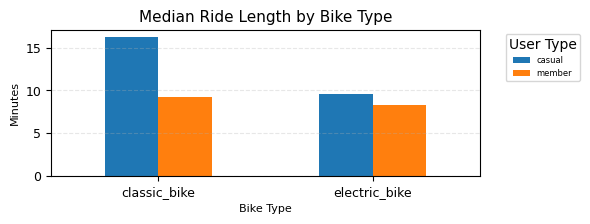

member_casual     casual    member
rideable_type                     
classic_bike   16.285183  9.231350
electric_bike   9.607383  8.271367


In [440]:
ride_length_bike = combined_df.groupby(['rideable_type', 'member_casual'])['ride_length_minutes'].median().unstack()

ride_length_bike.plot(kind='bar', color=colors)
style_plot(
    title='Median Ride Length by Bike Type',
    xlabel='Bike Type',
    ylabel='Minutes',
)
# Legend setting
plt.legend(
    title="User Type",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.xticks(rotation=0)
plt.show()
print(ride_length_bike)

### Identification of Potential Member Conversion Segment

A subset of casual riders was identified based on commute-hour usage and shorter ride durations to highlight users whose behavior closely resembles that of members. This group represents potential candidates for targeted membership conversion strategies.

In [441]:
potential = combined_df[
    (combined_df['member_casual'] == 'casual') &
    (combined_df['is_commute_hour'] == 1) &
    (combined_df['ride_length_minutes'] < 30)
]

print("Potential converters:", potential.shape[0])

potential.groupby('day_type').size()

Potential converters: 454749


day_type
Weekday    454749
dtype: int64

In [442]:
potential['ride_length_minutes'].describe()

count    454749.000000
mean         10.683680
std           6.804959
min           0.001100
25%           5.534617
50%           9.187650
75%          14.702583
max          29.998500
Name: ride_length_minutes, dtype: float64

### Summary of Analysis

#### Hourly Ride Patterns
Members show clear peaks during morning (7–9 AM) and evening (4–6 PM) commute hours, indicating work-related usage. In contrast, casual riders peak in the afternoon and early evening, suggesting more flexible, leisure-oriented riding behavior.

#### Monthly Ride Trends
Ride activity increases steadily from spring, peaks during summer months, and declines sharply in winter. This pattern reflects strong seasonality, with warmer weather driving higher usage across both user types.

#### Seasonal Ride Patterns
Bike usage is highest in summer and lowest in winter. Casual riders show a more pronounced increase during peak seasons, reinforcing their sensitivity to weather and recreational use.

#### Day of Week Usage
Members maintain consistent usage throughout the weekdays, while casual riders show noticeable spikes on weekends. This highlights a distinction between routine commuting and leisure riding patterns.

#### Ride Length by Time Segment
Ride duration is generally longest during the afternoon across both user types. Casual riders consistently take longer trips in all time segments, further supporting their leisure-focused behavior.

#### Bike Type Usage
Electric bikes are used frequently across both groups, indicating strong adoption of this option. Usage patterns suggest that both members and casual riders value convenience and efficiency.

#### Ride Length by Bike Type
Casual riders take significantly longer trips than members across all bike types, especially with classic bikes. Members exhibit shorter and more consistent ride durations, regardless of bike type.

#### Weekday vs Weekend Usage
Members predominantly ride on weekdays, aligning with commuting behavior, while casual riders show increased activity on weekends, reinforcing their recreational usage patterns.

#### Conversion Opportunity Analysis
A segment of casual riders demonstrates commuter-like behavior, characterized by short rides during weekday commute hours. This group represents a high-potential target for membership conversion due to their similarity to member usage patterns.


### Final Analytical Insight

Across all dimensions—time, duration, and usage patterns—members exhibit structured, routine behavior, while casual riders display flexible, leisure-driven usage. However, the presence of commuter-like casual riders presents a clear opportunity for targeted conversion strategies.

### Visualization & Key Findings


<img src = "../images/cyclistic_dashboard.png"/>
The dashboard visualizes rider behavior across time, duration, and bike usage, highlighting clear differences between members and casual riders.

Members demonstrate structured and consistent usage patterns, with strong peaks during weekday commute hours and relatively shorter ride durations. This indicates that members primarily use the service for daily transportation. In contrast, casual riders exhibit more flexible and leisure-oriented behavior, with higher activity during afternoons and weekends, as well as longer ride durations across all scenarios.

Seasonal and monthly trends show that bike usage increases significantly during warmer months, peaking in summer, and declines sharply in winter. Casual riders are more sensitive to these seasonal changes, suggesting their usage is more influenced by weather and recreational factors.

Analysis of ride characteristics further reveals that casual riders consistently take longer trips regardless of bike type, particularly with classic bikes, while members maintain shorter and more efficient rides. Additionally, ride duration tends to be longest during the afternoon period for both groups.

A key finding from the analysis is the identification of a segment of casual riders who display commuter-like behavior, characterized by short rides during weekday commute hours. This group represents a strong opportunity for conversion into members, as their usage patterns closely resemble those of existing subscribers.

Overall, the visualizations highlight distinct behavioral patterns, strong seasonality, and a clear opportunity to drive membership growth through targeted strategies.

### Recommendations

Based on the analysis of rider behavior, the following strategic recommendations are proposed to increase membership conversion and overall engagement:

#### 1. Target Commuter-Like Casual Riders with Membership Incentives
A segment of casual riders exhibits behavior similar to members, characterized by short rides during weekday commute hours. This group represents the highest conversion potential.

**Recommendation:** <br>
Develop targeted campaigns offering discounted memberships, free trial periods, or commuter-specific plans to encourage this segment to transition into members.


#### 2. Leverage Seasonal Peaks with Timed Promotions
Ride activity significantly increases during spring and summer, particularly among casual riders who are more influenced by favorable weather conditions.

**Recommendation:** <br>
Launch seasonal marketing campaigns during peak months, highlighting the cost savings and convenience of membership to convert high-volume casual riders when engagement is highest.


#### 3. Promote Value of Membership for Frequent and Long-Duration Riders
Casual riders consistently take longer trips and may incur higher per-ride costs compared to members.

**Recommendation:** <br>
Communicate the financial and convenience benefits of membership through pricing comparisons, in-app messaging, and targeted outreach to frequent users, emphasizing long-term savings.

### Final Case Study Conclusion

This analysis demonstrates that members and casual riders exhibit fundamentally different usage behaviors, with members showing structured, commute-driven patterns and casual riders displaying more flexible, leisure-oriented activity. Seasonal trends further highlight that ridership is heavily influenced by weather, with peak usage occurring during warmer months.

Most importantly, the identification of a segment of casual riders with commuter-like behavior presents a clear and actionable opportunity for conversion. By targeting this group with tailored incentives and strategically timed campaigns, Cyclistic can effectively increase membership adoption and drive long-term customer value.

Overall, this project highlights the importance of combining data analysis with business context to uncover meaningful insights and support data-driven decision-making.
